<a href="https://colab.research.google.com/github/beseka/artist-lyric-matching-nlp/blob/main/hw1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Data Loading and Concatenation

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path

hw1_dir = Path('/content/drive/MyDrive/cs445/hw1/csv')

csv_paths = sorted(hw1_dir.glob('*.csv'))
csv_paths

# I downloaded and added the kaggle csv files which is in zip file to drive for using, I did not use zip file directly.

[PosixPath('/content/drive/MyDrive/cs445/hw1/csv/ArianaGrande.csv'),
 PosixPath('/content/drive/MyDrive/cs445/hw1/csv/BTS.csv'),
 PosixPath('/content/drive/MyDrive/cs445/hw1/csv/Beyonce.csv'),
 PosixPath('/content/drive/MyDrive/cs445/hw1/csv/BillieEilish.csv'),
 PosixPath('/content/drive/MyDrive/cs445/hw1/csv/CardiB.csv'),
 PosixPath('/content/drive/MyDrive/cs445/hw1/csv/CharliePuth.csv'),
 PosixPath('/content/drive/MyDrive/cs445/hw1/csv/ColdPlay.csv'),
 PosixPath('/content/drive/MyDrive/cs445/hw1/csv/Drake.csv'),
 PosixPath('/content/drive/MyDrive/cs445/hw1/csv/DuaLipa.csv'),
 PosixPath('/content/drive/MyDrive/cs445/hw1/csv/EdSheeran.csv'),
 PosixPath('/content/drive/MyDrive/cs445/hw1/csv/Eminem.csv'),
 PosixPath('/content/drive/MyDrive/cs445/hw1/csv/JustinBieber.csv'),
 PosixPath('/content/drive/MyDrive/cs445/hw1/csv/KatyPerry.csv'),
 PosixPath('/content/drive/MyDrive/cs445/hw1/csv/Khalid.csv'),
 PosixPath('/content/drive/MyDrive/cs445/hw1/csv/LadyGaga.csv'),
 PosixPath('/content/dri

In [ ]:
import pandas as pd

def read_csv_flex(p):
    try:
        return pd.read_csv(p, encoding='utf-8-sig')
    except UnicodeDecodeError:
        try:
            return pd.read_csv(p, encoding='cp1254')
        except Exception:
            try:
                return pd.read_csv(p, sep=';', encoding='utf-8-sig')
            except Exception:
                return pd.read_csv(p, sep=';', encoding='cp1254')

dfs = {p.stem: read_csv_flex(p) for p in csv_paths}

list(dfs.keys())[:5], dfs[next(iter(dfs))].head()

# Reading tryings for accessing every csv control

(['ArianaGrande', 'BTS', 'Beyonce', 'BillieEilish', 'CardiB'],
           Artist                   Title            Album        Date  \
 0  Ariana Grande          ​thank u, next    thank u, next  2018-11-03   
 1  Ariana Grande                 7 rings    thank u, next  2019-01-18   
 2  Ariana Grande         ​God is a woman        Sweetener  2018-07-13   
 3  Ariana Grande            Side To Side  Dangerous Woman  2016-05-20   
 4  Ariana Grande  ​​no tears left to cry        Sweetener  2018-04-20   
 
                                                Lyric    Year  
 0  thought i'd end up with sean but he wasn't a m...  2018.0  
 1  yeah breakfast at tiffany's and bottles of bub...  2019.0  
 2  you you love it how i move you you love it how...  2018.0  
 3  ariana grande  nicki minaj i've been here all ...  2016.0  
 4  right now i'm in a state of mind i wanna be in...  2018.0  )

In [ ]:
dfs_tagged = []
for p in csv_paths:
    df = read_csv_flex(p)
    df['__source_file'] = p.name
    dfs_tagged.append(df)

combined = pd.concat(dfs_tagged, ignore_index=True)
combined.head()

# I concantated them alphabetically into combined df.


,Artist,Title,Album,Date,Lyric,Year,__source_file,Unnamed: 0
0,Ariana Grande,"​thank u, next","thank u, next",2018-11-03,thought i'd end up with sean but he wasn't a m...,2018.0,ArianaGrande.csv,NaN
1,Ariana Grande,7 rings,"thank u, next",2019-01-18,yeah breakfast at tiffany's and bottles of bub...,2019.0,ArianaGrande.csv,NaN
2,Ariana Grande,​God is a woman,Sweetener,2018-07-13,you you love it how i move you you love it how...,2018.0,ArianaGrande.csv,NaN
3,Ariana Grande,Side To Side,Dangerous Woman,2016-05-20,ariana grande nicki minaj i've been here all ...,2016.0,ArianaGrande.csv,NaN
4,Ariana Grande,​​no tears left to cry,Sweetener,2018-04-20,right now i'm in a state of mind i wanna be in...,2018.0,ArianaGrande.csv,NaN


In [ ]:
out_path = Path('/content/drive/MyDrive/cs445/hw1/combined.csv')
combined.to_csv(out_path, index=False, encoding='utf-8-sig')
out_path

# I upload the raw version of combined df to drive for just controlling and examination.

PosixPath('/content/drive/MyDrive/cs445/hw1/combined.csv')

In [ ]:
len(combined)

6027

# 2. Data Cleaning

In [ ]:
combined.keys()

Index(['Artist', 'Title', 'Album', 'Date', 'Lyric', 'Year', '__source_file',
       'Unnamed: 0'],
      dtype='object')

In [ ]:
import re
print("raw len(combined):", len(combined))

# null checking
combined['Lyric']  = combined['Lyric'].fillna("").astype(str)
combined['Artist'] = combined['Artist'].fillna("").astype(str)
df2 = combined[(combined['Lyric'].str.strip() != "") & (combined['Artist'].str.strip() != "")].copy()

# exactly same rows (Artist + Lyric same)
before_dups = len(df2)
df2 = df2.drop_duplicates(subset=['Artist', 'Lyric'])
after_dups = len(df2)

print("repeated rows:", before_dups - after_dups)


# creating clean data after cleaning
combined_clean = df2.reset_index(drop=True)
print("combined_clean len:", len(combined_clean))

raw len(combined): 6027
repeated rows: 315
combined_clean len: 5666


# 3. EDA - *Artist Histogram*

In [ ]:
artist_counts = combined_clean['Artist'].value_counts()
artist_counts2 = combined['Artist'].value_counts()

print("Before: Raw List")
print("\n",artist_counts2)
print("\nAfter: Cleaned List")
print("\n",artist_counts)

Before: Raw List

 Artist
Eminem           521
Taylor Swift     479
Drake            466
Beyoncé          406
Rihanna          405
Lady Gaga        402
Justin Bieber    348
Coldplay         344
Katy Perry       325
Nicki Minaj      323
Ariana Grande    308
Ed Sheeran       296
BTS (방탄소년단)      278
Dua Lipa         247
Maroon 5         197
Selena Gomez     175
Post Malone      148
Billie Eilish    145
Cardi B           75
Charlie Puth      75
Khalid            64
Name: count, dtype: int64

After: Cleaned List

 Artist
Eminem           515
Drake            462
Taylor Swift     449
Beyoncé          380
Lady Gaga        367
Rihanna          360
Coldplay         325
Justin Bieber    322
Nicki Minaj      307
Ariana Grande    296
Ed Sheeran       285
Katy Perry       274
BTS (방탄소년단)      268
Dua Lipa         213
Maroon 5         191
Selena Gomez     155
Post Malone      148
Billie Eilish    136
Cardi B           75
Charlie Puth      75
Khalid            63
Name: count, dtype: int64


/tmp/ipython-input-3404621247.py:11: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3404621247.py:11: UserWarning: Glyph 53444 (\N{HANGUL SYLLABLE TAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3404621247.py:11: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3404621247.py:11: UserWarning: Glyph 45380 (\N{HANGUL SYLLABLE NYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3404621247.py:11: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning

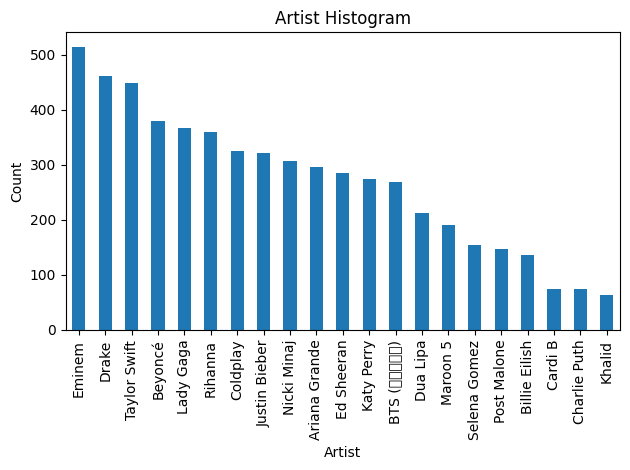

In [ ]:
import matplotlib.pyplot as plt

artist_counts = combined_clean['Artist'].value_counts()


plt.figure()
artist_counts.head(30).plot(kind='bar')
plt.title('Artist Histogram')
plt.xlabel('Artist')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


#We can see the artist/ lyric value histogram below

# 4. Preprocessing


In [ ]:
import re
import pandas as pd

def preprocess_data(df: pd.DataFrame, min_token: int = 5) -> pd.DataFrame:
    """
    this preprocess function is about normalization and standartization, ı already cleaned data
    and this functions helps for standartizaton of lyric lines
    """
    # helper regex for unique artist-lyrics relation removed same words not included the lyrics
    RE_SQUARE = re.compile(r"\[[^\]]+\]")       # [Chorus], [Verse 1], ...
    RE_PAREN  = re.compile(r"\([^)]*\)")        # (x2), (Repeat), ...
    RE_URL    = re.compile(r"https?://\S+|www\.\S+")
    RE_MISC   = re.compile(r"(embed\s*\d*|\bchorus\b|\bverse\b|\bbridge\b)", re.IGNORECASE)

    def _clean_lyric_text(text: str) -> str:
        if not isinstance(text, str):
            return ""
        lines = []
        for line in text.splitlines():
            line = line.strip()
            if not line or len(line) <= 1:
                continue
            line = RE_URL.sub(" ", line)
            line = RE_MISC.sub(" ", line)
            line = RE_SQUARE.sub(" ", line)
            line = RE_PAREN.sub(" ", line)
            line = re.sub(r"[^\w\s\'’\-]", " ", line)
            line = re.sub(r"\s+", " ", line).strip()
            if line:
                lines.append(line)
        t = " ".join(lines).lower()
        return re.sub(r"\s+", " ", t).strip()

    out = df.copy()
    out['Lyric'] = out['Lyric'].fillna("").astype(str).apply(_clean_lyric_text)
    # short lyrics
    if min_token is not None and min_token > 0:
        out = out[out['Lyric'].str.split().str.len() >= min_token].reset_index(drop=True)
    return out

# Kullanım:
print("Before lyric normalization len:", len(combined_clean))
combined_clean = preprocess_data(combined_clean, min_token=5)
print("After lyric normalization len:", len(combined_clean))


Metin normalize öncesi len: 5666
Metin normalize sonrası len: 5622


In [ ]:
# --------------- Train / Dev / Test split ---------------

from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

SEED = 42  # same seed for every experiment

# only uses Artist and Lyrics
df_split = combined_clean[['Artist', 'Lyric']].copy()

# controlling and ensuring numbers of every class
counts = df_split['Artist'].value_counts()
keep_artists = counts[counts >= 3].index
dropped_artists = set(df_split['Artist']) - set(keep_artists)
if dropped_artists:
    print(f"warning: {len(dropped_artists)} artist removed (sample < 3).")
df_split = df_split[df_split['Artist'].isin(keep_artists)].reset_index(drop=True)

X = df_split['Lyric'].values
y = df_split['Artist'].values

# test => 15%
X_train_dev, X_test, y_train_dev, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)

# dev (0.15 / 0.85) => 15% dev
dev_ratio_in_remaining = 0.15 / 0.85
X_train, X_dev, y_train, y_dev = train_test_split(
    X_train_dev, y_train_dev,
    test_size=dev_ratio_in_remaining, random_state=SEED, stratify=y_train_dev
)

# Percentages
n = len(X)
print(f"Total: {n}")
print(f"Train: {len(X_train)} ({len(X_train)/n:.2%})")
print(f"Dev:    {len(X_dev)}   ({len(X_dev)/n:.2%})")
print(f"Test:   {len(X_test)}  ({len(X_test)/n:.2%})")

# Class distribution control
def summarize_split(name, y_):
    vc = pd.Series(y_).value_counts(normalize=True)
    print(f"\n{name} class ratio (top 10):")
    print((vc.head(10) * 100).round(2).astype(str) + '%')

summarize_split("Train", y_train)
summarize_split("Dev", y_dev)
summarize_split("Test", y_test)


Total: 5622
Train: 3934 (69.98%)
Dev:    844   (15.01%)
Test:   844  (15.01%)

Train class ratio (top 10):
Eminem           9.07%
Drake            8.13%
Taylor Swift     8.01%
Beyoncé          6.74%
Rihanna          6.38%
Lady Gaga        6.38%
Coldplay         5.77%
Justin Bieber    5.67%
Nicki Minaj      5.36%
Ariana Grande    5.19%
Name: proportion, dtype: object

Dev class ratio (top 10):
Eminem            9.0%
Drake            8.18%
Taylor Swift     7.94%
Beyoncé          6.75%
Lady Gaga         6.4%
Rihanna           6.4%
Coldplay         5.81%
Justin Bieber    5.69%
Nicki Minaj      5.33%
Ariana Grande    5.21%
Name: proportion, dtype: object

Test class ratio (top 10):
Eminem           9.12%
Drake            8.18%
Taylor Swift     7.94%
Beyoncé          6.75%
Lady Gaga         6.4%
Rihanna           6.4%
Coldplay         5.81%
Justin Bieber    5.69%
Nicki Minaj      5.33%
Ariana Grande    5.21%
Name: proportion, dtype: object


# 5. Naive Bayes

In [ ]:
# this cell and section is only for naive bayes implementation, multinomial naive bayes and ı use laplace for smoothing for better results
# there is no library for it, also ı wrote tokenizer

from collections import Counter
import numpy as np
import math
import pandas as pd

class NaiveBayesBoW:
    def __init__(self, alpha: float = 1.0, min_df: int = 1, max_features: int | None = None):
        self.alpha = alpha
        self.min_df = min_df
        self.max_features = max_features
        # learning parameters
        self.classes_ = None
        self.class_priors_log_ = {}      # log P(c)
        self.vocab_ = {}                 # token -> idx
        self.idx2tok_ = []               # idx -> token
        self.class_token_counts_ = {}    # c -> Counter(token)
        self.class_total_tokens_ = {}    # c -> total token number
        self.class_token_loglik_ = {}    # c -> {tok: log P(tok|c)}
        self.fallback_loglik_ = {}       # c -> OOV for log P(UNK|c)

    def _tokenize(self, text: str):
        return text.split()

    def _build_vocab(self, docs):
        # token document frequency
        df_counter = Counter()
        for doc in docs:
            df_counter.update(set(self._tokenize(doc)))
        # min_df filter
        items = [(tok, df) for tok, df in df_counter.items() if df >= self.min_df]
        # common ones
        items.sort(key=lambda x: x[1], reverse=True)
        if self.max_features is not None:
            items = items[:self.max_features]
        self.idx2tok_ = [tok for tok, _ in items]
        self.vocab_ = {tok: i for i, tok in enumerate(self.idx2tok_)}

    def fit(self, X_train, y_train):
        y_train = np.asarray(y_train)
        self.classes_, counts = np.unique(y_train, return_counts=True)
        n = len(y_train)
        # top probabilities P(c)
        for c, cnt in zip(self.classes_, counts):
            self.class_priors_log_[c] = math.log(cnt / n)

        # vocab from train
        self._build_vocab(X_train)
        V = len(self.vocab_)

        # class based counting
        self.class_token_counts_ = {c: Counter() for c in self.classes_}
        self.class_total_tokens_ = {c: 0 for c in self.classes_}

        for text, c in zip(X_train, y_train):
            toks = self._tokenize(text)
            self.class_token_counts_[c].update(toks)
            self.class_total_tokens_[c] += len(toks)

        # log P(w|c) and OOV fallback comes from formula of naive bayes
        self.class_token_loglik_ = {c: {} for c in self.classes_}
        self.fallback_loglik_ = {}
        for c in self.classes_:
            Nc = self.class_total_tokens_[c]
            denom = Nc + self.alpha * V
            self.fallback_loglik_[c] = math.log(self.alpha / denom)
            counts_c = self.class_token_counts_[c]
            for tok in self.vocab_:
                num = counts_c.get(tok, 0) + self.alpha
                self.class_token_loglik_[c][tok] = math.log(num / denom)
        return self

    def predict_log_proba(self, X):
        log_probs = np.zeros((len(X), len(self.classes_)), dtype=float)
        for i, text in enumerate(X):
            tok_counts = Counter(self._tokenize(text))  # BoW: frequencies
            for j, c in enumerate(self.classes_):
                s = self.class_priors_log_[c]
                for tok, cnt in tok_counts.items():
                    if tok in self.vocab_:
                        s += cnt * self.class_token_loglik_[c][tok]
                    else:
                        s += cnt * self.fallback_loglik_[c]
                log_probs[i, j] = s
        return log_probs

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_log_proba(X), axis=1)]


# 6. Feature Selection and Engineering for Logistic Regression and SVM

In [ ]:
# Word TF-IDF (1–2-gram) + Character TF-IDF (3–5-gram) --> merge
# DİKKAT: Vectorizers are only fit in train; applied transformation on dev/test.

from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

# word-level TF-IDF
tfidf_word = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.9)
# char-level TF-IDF
tfidf_char = TfidfVectorizer(analyzer='char', ngram_range=(3, 5), min_df=2, max_df=0.9)

# fit only on TRAIN
Xtr_w  = tfidf_word.fit_transform(X_train)
Xtr_c  = tfidf_char.fit_transform(X_train)
Xtr    = hstack([Xtr_w, Xtr_c])

# transform DEV/TEST
Xdev_w = tfidf_word.transform(X_dev)
Xdev_c = tfidf_char.transform(X_dev)
Xdev   = hstack([Xdev_w, Xdev_c])

Xtest_w = tfidf_word.transform(X_test)
Xtest_c = tfidf_char.transform(X_test)
Xtest   = hstack([Xtest_w, Xtest_c])


# 7. Model Training and Evaluations


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42
classes_all = np.unique(np.concatenate([y_train, y_dev, y_test], axis=0))

def plot_cm(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(cm, interpolation='nearest', aspect='auto')
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=labels, yticklabels=labels,
        title=title, ylabel='Actual', xlabel='Predicted'
    )
    plt.setp(ax.get_xticklabels(), rotation=90, ha="center")
    ax.set_ylim(len(labels)-0.5, -0.5)
    plt.tight_layout()
    plt.show()

In [ ]:
# NB  — TRAIN fit, DEV evaluation
nb = NaiveBayesBoW(alpha=1.0, min_df=2)
nb.fit(X_train, y_train)
pred_nb_dev = nb.predict(X_dev)

acc_nb_dev = accuracy_score(y_dev, pred_nb_dev)
f1_nb_dev  = f1_score(y_dev, pred_nb_dev, average='macro')
print(f"[DEV] NB(scratch) -> Acc: {acc_nb_dev:.4f} | F1(macro): {f1_nb_dev:.4f}")

[DEV] NB(scratch) -> Acc: 0.6315 | F1(macro): 0.5470


In [ ]:
# Logistic Regression — TF-IDF (Xtr/Xdev)
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(C=2.0, max_iter=2000, solver='saga', n_jobs=-1, random_state=SEED)
logreg.fit(Xtr, y_train)
pred_lr_dev = logreg.predict(Xdev)

acc_lr_dev = accuracy_score(y_dev, pred_lr_dev)
f1_lr_dev  = f1_score(y_dev, pred_lr_dev, average='macro')
print(f"[DEV] Logistic Regression -> Acc: {acc_lr_dev:.4f} | F1(macro): {f1_lr_dev:.4f}")


[DEV] Logistic Regression -> Acc: 0.7156 | F1(macro): 0.6582


In [ ]:
# Linear SVM — TF-IDF (Xtr/Xdev)
from sklearn.svm import LinearSVC

svm = LinearSVC(C=1.0, random_state=SEED)
svm.fit(Xtr, y_train)
pred_svm_dev = svm.predict(Xdev)

acc_svm_dev = accuracy_score(y_dev, pred_svm_dev)
f1_svm_dev  = f1_score(y_dev, pred_svm_dev, average='macro')
print(f"[DEV] Linear SVM -> Acc: {acc_svm_dev:.4f} | F1(macro): {f1_svm_dev:.4f}")

[DEV] Linear SVM -> Acc: 0.7239 | F1(macro): 0.6818


In [ ]:
# DEV summary
summary_dev = pd.DataFrame({
    'model': ['NB_scratch', 'LogReg', 'LinearSVM'],
    'acc':   [acc_nb_dev, acc_lr_dev, acc_svm_dev],
    'f1_macro': [f1_nb_dev, f1_lr_dev, f1_svm_dev]
}).sort_values(by=['acc','f1_macro'], ascending=False)
summary_dev


,model,acc,f1_macro
2,LinearSVM,0.723934,0.681829
1,LogReg,0.715640,0.658157
0,NB_scratch,0.631517,0.547002


/tmp/ipython-input-464811668.py:22: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-464811668.py:22: UserWarning: Glyph 53444 (\N{HANGUL SYLLABLE TAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-464811668.py:22: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-464811668.py:22: UserWarning: Glyph 45380 (\N{HANGUL SYLLABLE NYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-464811668.py:22: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Gly

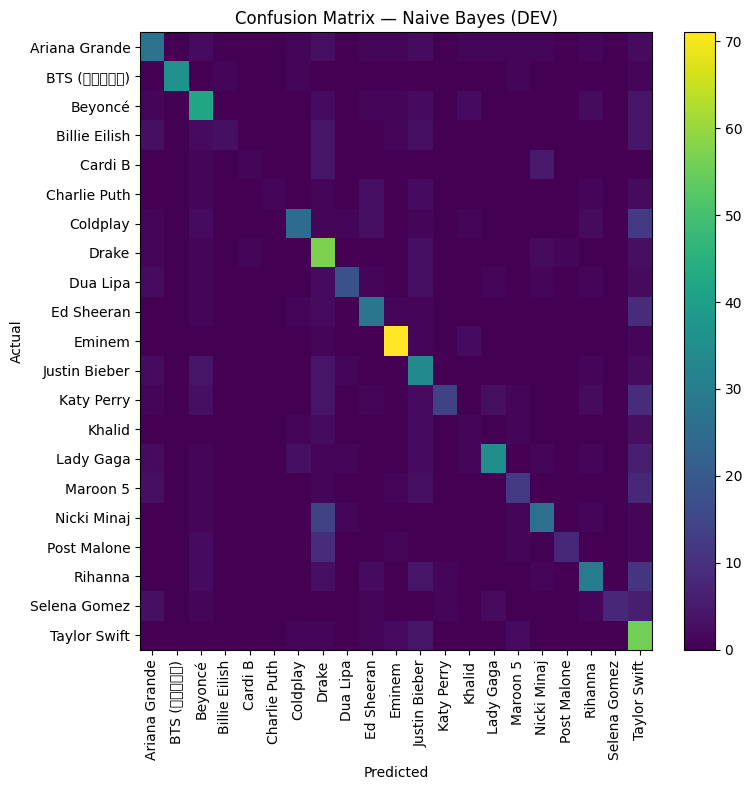

In [ ]:
# DEV Confusion Matrix — Naive Bayes
plot_cm(y_dev, pred_nb_dev, classes_all, "Confusion Matrix — Naive Bayes (DEV)")

/tmp/ipython-input-464811668.py:22: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-464811668.py:22: UserWarning: Glyph 53444 (\N{HANGUL SYLLABLE TAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-464811668.py:22: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-464811668.py:22: UserWarning: Glyph 45380 (\N{HANGUL SYLLABLE NYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-464811668.py:22: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Gly

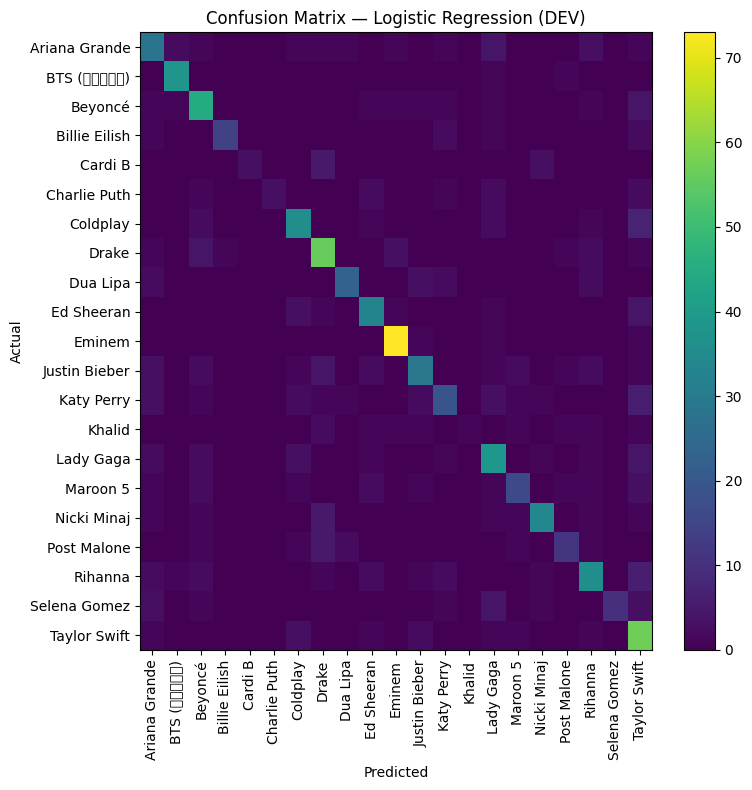

In [ ]:
# DEV CM — Logistic Regression
plot_cm(y_dev, pred_lr_dev, classes_all, "Confusion Matrix — Logistic Regression (DEV)")

/tmp/ipython-input-464811668.py:22: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-464811668.py:22: UserWarning: Glyph 53444 (\N{HANGUL SYLLABLE TAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-464811668.py:22: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-464811668.py:22: UserWarning: Glyph 45380 (\N{HANGUL SYLLABLE NYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-464811668.py:22: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Gly

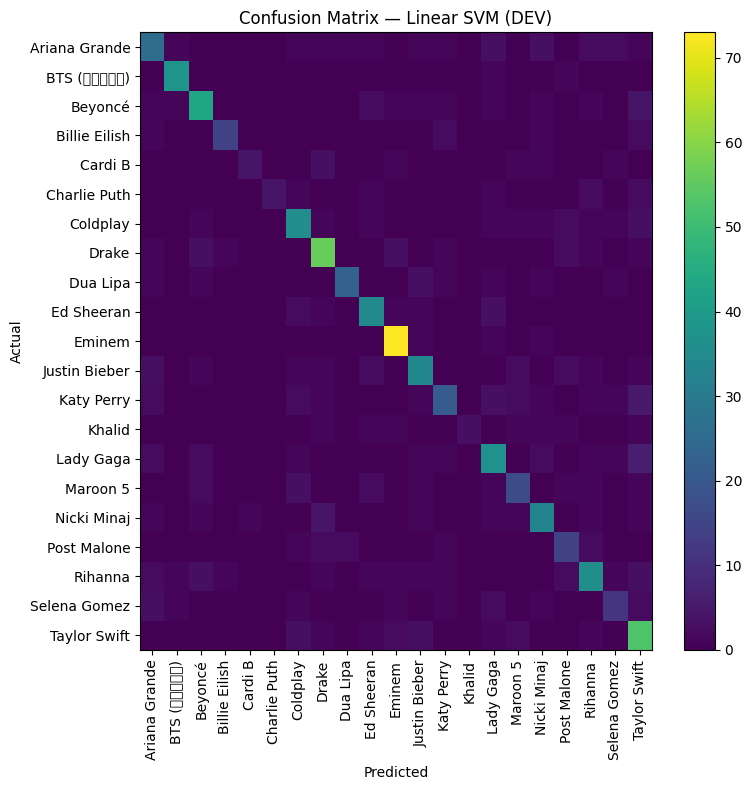

In [ ]:
#DEV CM — Linear SVM
plot_cm(y_dev, pred_svm_dev, classes_all, "Confusion Matrix — Linear SVM (DEV)")

In [ ]:
# Best Model on Dev
scores_dev = {
    'nb':  (acc_nb_dev,  f1_nb_dev),
    'lr':  (acc_lr_dev,  f1_lr_dev),
    'svm': (acc_svm_dev, f1_svm_dev),
}
best_name = max(scores_dev, key=lambda k: (scores_dev[k][0], scores_dev[k][1]))
print("Best on DEV:", best_name, "-> Acc:", scores_dev[best_name][0], "| F1:", scores_dev[best_name][1])


Best on DEV: svm -> Acc: 0.7239336492890995 | F1: 0.6818290886898397


In [ ]:
# 7.10) train+dev and fit best model on it and evaluate in test
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

X_trd = np.concatenate([X_train, X_dev])
y_trd = np.concatenate([y_train, y_dev])

if best_name == 'nb':
    # NB
    nb_final = NaiveBayesBoW(alpha=1.0, min_df=2).fit(X_trd, y_trd)
    y_test_pred = nb_final.predict(X_test)
else:
    # fit TF-IDF on test set
    tfidf_word_final = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.9)
    tfidf_char_final = TfidfVectorizer(analyzer='char', ngram_range=(3,5), min_df=2, max_df=0.9)

    Xtrd_w = tfidf_word_final.fit_transform(X_trd)
    Xtrd_c = tfidf_char_final.fit_transform(X_trd)
    Xtrd    = hstack([Xtrd_w, Xtrd_c])

    Xtest_w = tfidf_word_final.transform(X_test)
    Xtest_c = tfidf_char_final.transform(X_test)
    Xtest   = hstack([Xtest_w, Xtest_c])

    if best_name == 'lr':
        model_final = LogisticRegression(C=2.0, max_iter=2000, solver='saga', n_jobs=-1, random_state=SEED)
    else:  # 'svm'
        model_final = LinearSVC(C=1.0, random_state=SEED)

    model_final.fit(Xtrd, y_trd)
    y_test_pred = model_final.predict(Xtest)

test_acc = accuracy_score(y_test, y_test_pred)
test_f1  = f1_score(y_test, y_test_pred, average='macro')
print(f"[FINAL - TEST] {best_name.upper()} -> Acc: {test_acc:.4f} | F1(macro): {test_f1:.4f}")


[FINAL - TEST] SVM -> Acc: 0.7405 | F1(macro): 0.7125


/tmp/ipython-input-464811668.py:22: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-464811668.py:22: UserWarning: Glyph 53444 (\N{HANGUL SYLLABLE TAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-464811668.py:22: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-464811668.py:22: UserWarning: Glyph 45380 (\N{HANGUL SYLLABLE NYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-464811668.py:22: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Gly

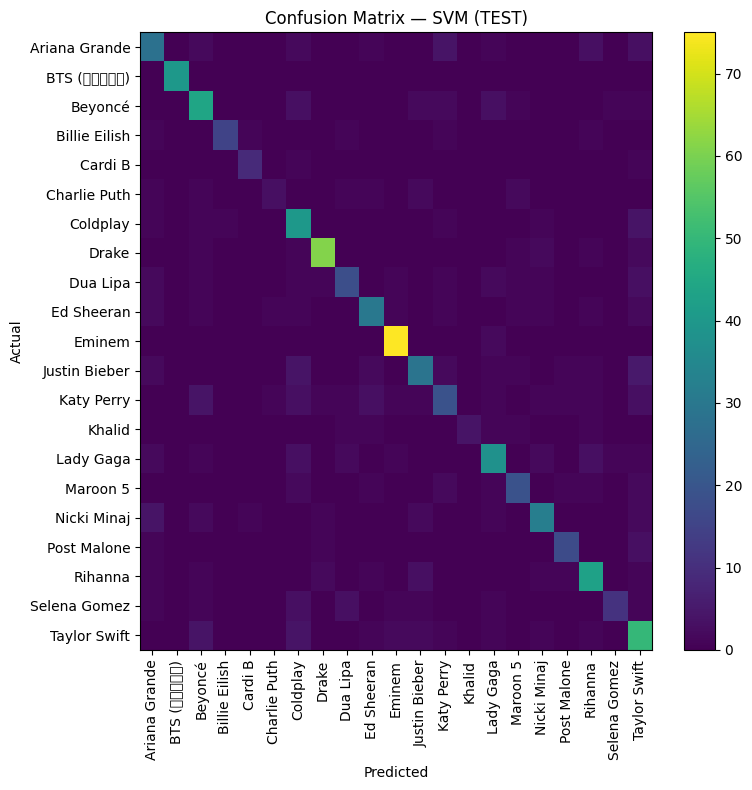

In [ ]:
#TEST CM — Best Model
plot_cm(y_test, y_test_pred, classes_all, f"Confusion Matrix — {best_name.upper()} (TEST)")


# Report

 I created preprocessing function strictly using lyrics only. After loading and concatenating the CSVs, I cleaned the data by removing empty/NULL rows, and dropping exact duplicates on (Artist, Lyric). I normalized the text by stripping URLs and structural tags like “[Chorus]”, “[Verse]”, and parenthetical asides, lowercasing, keeping only alphanumerics plus apostrophes/hyphens, collapsing whitespace, and discarding very short lyrics (<5 tokens).  I performed a stratified 70/15/15 train/dev/test split with a fixed random_state=42 (seed) and excluded artists with fewer than three examples to make stratification viable; an artist histogram confirmed the skew in class frequencies. For features, I combined word-level TF-IDF (unigrams and bigrams) with character-level TF-IDF (3–5 grams) for the linear baselines because word n-grams capture topical/style sequences while char n-grams are robust to spelling variants and artist-specific stylistic markers. In contrast, my Naive Bayes class used a multinomial bag-of-words with Laplace smoothing and vocabulary learned on the training set. I compared three models—Naive Bayes, Logistic Regression, and Linear SVM because these are strong, interpretable text baselines that work well with sparse features. On the dev set, Linear SVM performed best (Acc 0.724, macro-F1 0.682), followed by Logistic Regression (0.716/0.658) and Naive Bayes (0.632/0.547). After comparison on DEV set, I retrained the best model on train+dev and evaluated once on test, achieving Test Acc 0.7405 and macro-F1 0.7125, and I plotted confusion matrices for each model on dev and for the final model on test. One of the challanges is implementation of Naive Bayes. Naive Bayes required careful log-space computation for numerical stability, a closed-form fallback for OOV tokens under Laplace smoothing, and attention to vocabulary size and efficiency. Another one is avoiding any leakage by fitting vectorizers only on training data was also crucial. The main limitations are a simple whitespace tokenizer (no lemmatization/stopword strategy), NB using counts rather than TF-IDF or char n-grams, limited hyperparameter tuning, and no explicit handling of class imbalance beyond stratification. Possible improvements include systematic tuning of n-gram ranges, C, min_df/max_df, and stopwords; integrating char n-grams into NB; experimenting with class weighting and lemmatization; and exploring compact neural with proper regularization.